In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("application_train.csv")

In [5]:
df_clean = df.copy()

In [6]:
df_clean["DAYS_EMPLOYED"] = (
    df_clean["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

In [7]:
df_features = df_clean.copy()

print(df_features.shape)

(307511, 122)


In [8]:
feature_tracker = []

df_features["CREDIT_INCOME_RATIO"] = (

    df_features["AMT_CREDIT"]

    /

    df_features["AMT_INCOME_TOTAL"]

)

feature_tracker.append("CREDIT_INCOME_RATIO")

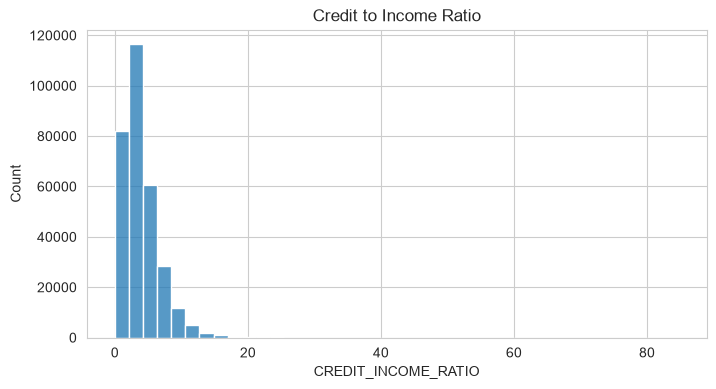

In [9]:
plt.figure(figsize=(8,4))

sns.histplot(

    df_features["CREDIT_INCOME_RATIO"],

    bins=40

)

plt.title("Credit to Income Ratio")

plt.show()

In [10]:
df_features["ANNUITY_INCOME_RATIO"] = (

    df_features["AMT_ANNUITY"]

    /

    df_features["AMT_INCOME_TOTAL"]

)

feature_tracker.append("ANNUITY_INCOME_RATIO")

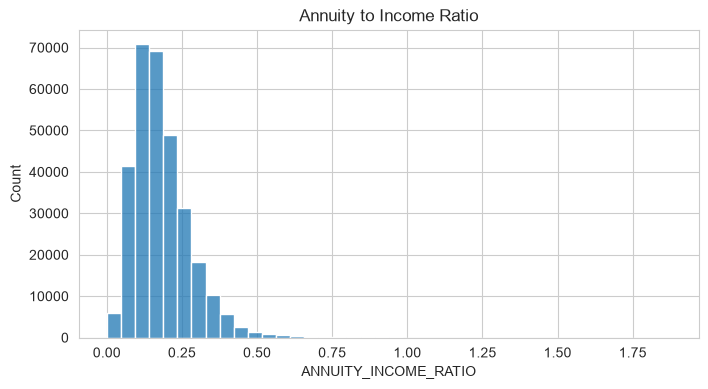

In [11]:
plt.figure(figsize=(8,4))

sns.histplot(

    df_features["ANNUITY_INCOME_RATIO"],

    bins=40

)

plt.title("Annuity to Income Ratio")

plt.show()

In [12]:
df_features["GOODS_CREDIT_RATIO"] = (

    df_features["AMT_GOODS_PRICE"]

    /

    df_features["AMT_CREDIT"]

)

feature_tracker.append("GOODS_CREDIT_RATIO")

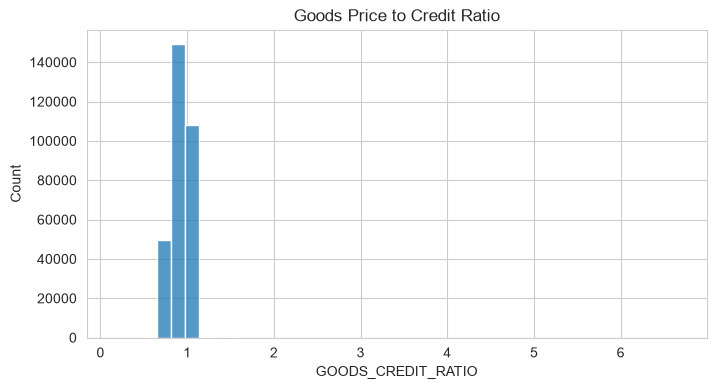

In [13]:
plt.figure(figsize=(8,4))

sns.histplot(

    df_features["GOODS_CREDIT_RATIO"],

    bins=40

)

plt.title("Goods Price to Credit Ratio")

plt.show()

In [14]:
feature_summary = pd.DataFrame({

    "Feature": feature_tracker,

    "Business Purpose": [

        "Loan relative to income",

        "Repayment burden",

        "Asset financing ratio"

    ]

})

feature_summary

,Feature,Business Purpose
0,CREDIT_INCOME_RATIO,Loan relative to income
1,ANNUITY_INCOME_RATIO,Repayment burden
2,GOODS_CREDIT_RATIO,Asset financing ratio


In [15]:
df_features.replace([np.inf, -np.inf], np.nan, inplace=True)

In [16]:
df_features["INCOME_PER_FAMILY_MEMBER"] = (
    df_features["AMT_INCOME_TOTAL"] /
    df_features["CNT_FAM_MEMBERS"]
)

feature_tracker.append("INCOME_PER_FAMILY_MEMBER")

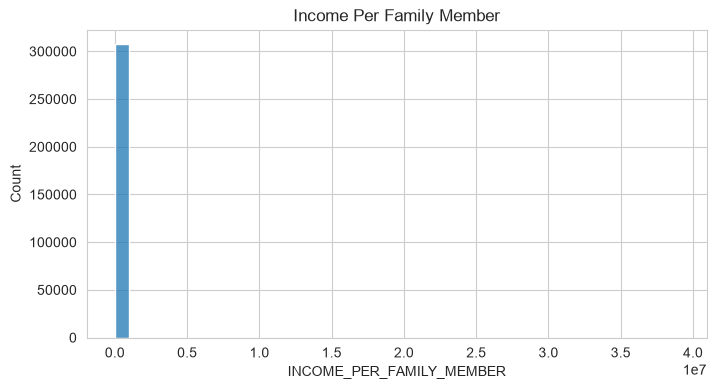

In [17]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_features["INCOME_PER_FAMILY_MEMBER"],
    bins=40
)

plt.title("Income Per Family Member")

plt.show()

In [18]:
df_features["CHILDREN_RATIO"] = (
    df_features["CNT_CHILDREN"] /
    df_features["CNT_FAM_MEMBERS"]
)

feature_tracker.append("CHILDREN_RATIO")

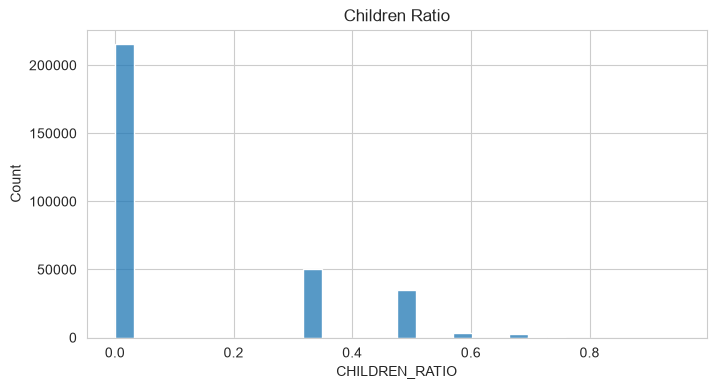

In [19]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_features["CHILDREN_RATIO"],
    bins=30
)

plt.title("Children Ratio")

plt.show()

In [20]:
df_features["CHILDREN_RATIO"].describe()

count    307509.000000
mean          0.125502
std           0.199578
min           0.000000
25%           0.000000
50%           0.000000
75%           0.333333
max           0.950000
Name: CHILDREN_RATIO, dtype: float64

In [21]:
df_features["AGE"] = (
    abs(df_features["DAYS_BIRTH"]) / 365
)

feature_tracker.append("AGE")

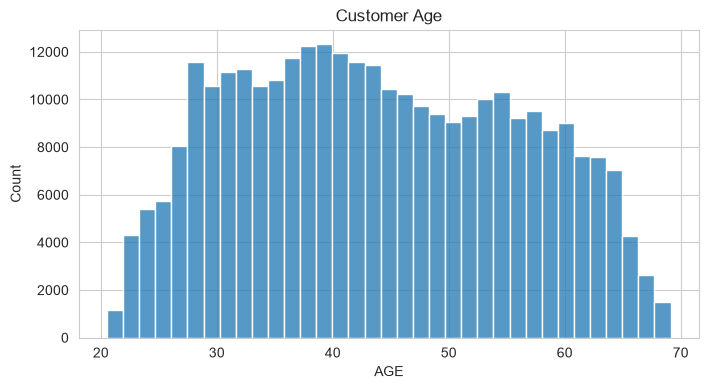

In [22]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_features["AGE"],
    bins=35
)

plt.title("Customer Age")

plt.show()

In [23]:
df_features["EMPLOYMENT_YEARS"] = (
    abs(df_features["DAYS_EMPLOYED"]) / 365
)

feature_tracker.append("EMPLOYMENT_YEARS")

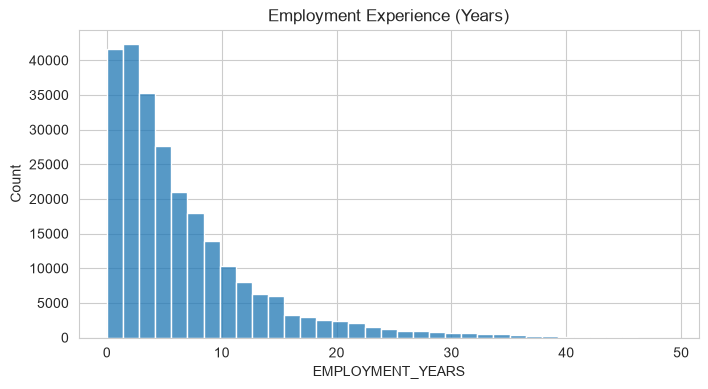

In [24]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_features["EMPLOYMENT_YEARS"],
    bins=35
)

plt.title("Employment Experience (Years)")

plt.show()

In [25]:
df_features["EMPLOYMENT_AGE_RATIO"] = (
    df_features["EMPLOYMENT_YEARS"] /
    df_features["AGE"]
)

feature_tracker.append("EMPLOYMENT_AGE_RATIO")

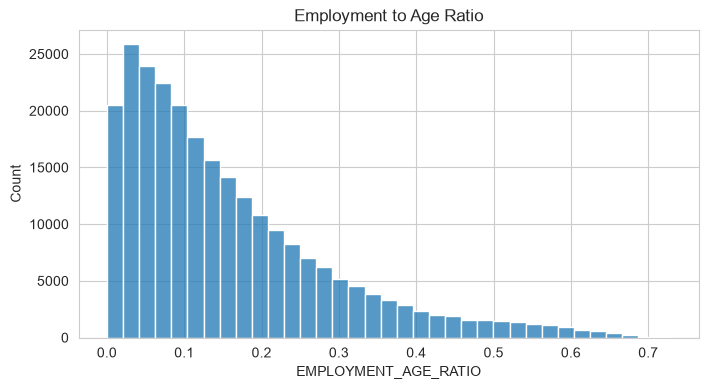

In [26]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_features["EMPLOYMENT_AGE_RATIO"],
    bins=35
)

plt.title("Employment to Age Ratio")

plt.show()

In [27]:
new_features = [
    "INCOME_PER_FAMILY_MEMBER",
    "CHILDREN_RATIO",
    "AGE",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_AGE_RATIO"
]

df_features[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
INCOME_PER_FAMILY_MEMBER,307509.0,93105.879645,101373.363394,2812.500000,47250.000000,75000.000000,112500.000000,3.900000e+07
CHILDREN_RATIO,307509.0,0.125502,0.199578,0.000000,0.000000,0.000000,0.333333,9.500000e-01
AGE,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,252137.0,6.531971,6.406466,0.000000,2.101370,4.515068,8.698630,4.907397e+01
EMPLOYMENT_AGE_RATIO,252137.0,0.156861,0.133549,0.000000,0.056099,0.118733,0.219170,7.288115e-01


In [28]:
df_features.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [29]:
feature_summary = pd.DataFrame({

    "Feature": feature_tracker

})

feature_summary

,Feature
0,CREDIT_INCOME_RATIO
1,ANNUITY_INCOME_RATIO
2,GOODS_CREDIT_RATIO
3,INCOME_PER_FAMILY_MEMBER
4,CHILDREN_RATIO
5,AGE
6,EMPLOYMENT_YEARS
7,EMPLOYMENT_AGE_RATIO


In [30]:
df_features["CREDIT_PER_FAMILY_MEMBER"] = (

    df_features["AMT_CREDIT"]

    /

    df_features["CNT_FAM_MEMBERS"]

)

feature_tracker.append("CREDIT_PER_FAMILY_MEMBER")

In [31]:
df_features["ANNUITY_PER_FAMILY_MEMBER"] = (

    df_features["AMT_ANNUITY"]

    /

    df_features["CNT_FAM_MEMBERS"]

)

feature_tracker.append("ANNUITY_PER_FAMILY_MEMBER")

In [32]:
df_features["CREDIT_GOODS_DIFF"] = (

    df_features["AMT_CREDIT"]

    -

    df_features["AMT_GOODS_PRICE"]

)

feature_tracker.append("CREDIT_GOODS_DIFF")

In [33]:
df_features["CREDIT_GOODS_RATIO_DIFF"] = (

    (

        df_features["AMT_CREDIT"]

        -

        df_features["AMT_GOODS_PRICE"]

    )

    /

    df_features["AMT_GOODS_PRICE"]

)

feature_tracker.append("CREDIT_GOODS_RATIO_DIFF")

In [34]:
df_features["INCOME_AFTER_ANNUITY"] = (

    df_features["AMT_INCOME_TOTAL"]

    -

    df_features["AMT_ANNUITY"]

)

feature_tracker.append("INCOME_AFTER_ANNUITY")

In [35]:
df_features["CREDIT_PER_CHILD"] = (

    df_features["AMT_CREDIT"]

    /

    (

        df_features["CNT_CHILDREN"]

        + 1

    )

)

feature_tracker.append("CREDIT_PER_CHILD")

In [36]:
df_features["INCOME_PER_CHILD"] = (

    df_features["AMT_INCOME_TOTAL"]

    /

    (

        df_features["CNT_CHILDREN"]

        + 1

    )

)

feature_tracker.append("INCOME_PER_CHILD")

In [37]:
df_features["DEPENDENCY_RATIO"] = (

    df_features["CNT_CHILDREN"]

    /

    df_features["CNT_FAM_MEMBERS"]

)

feature_tracker.append("DEPENDENCY_RATIO")

In [38]:
df_features["CREDIT_BURDEN_INDEX"] = (

    df_features["AMT_CREDIT"]

    +

    df_features["AMT_ANNUITY"]

) / df_features["AMT_INCOME_TOTAL"]

feature_tracker.append("CREDIT_BURDEN_INDEX")

In [39]:
df_features["FAMILY_FINANCIAL_BURDEN"] = (

    df_features["AMT_ANNUITY"]

    /

    df_features["CNT_FAM_MEMBERS"]

)

feature_tracker.append("FAMILY_FINANCIAL_BURDEN")

In [40]:
df_features.replace(

    [np.inf, -np.inf],

    np.nan,

    inplace=True

)

In [41]:
advanced_features = [

"CREDIT_PER_FAMILY_MEMBER",

"ANNUITY_PER_FAMILY_MEMBER",

"CREDIT_GOODS_DIFF",

"CREDIT_GOODS_RATIO_DIFF",

"INCOME_AFTER_ANNUITY",

"CREDIT_PER_CHILD",

"INCOME_PER_CHILD",

"DEPENDENCY_RATIO",

"CREDIT_BURDEN_INDEX",

"FAMILY_FINANCIAL_BURDEN"

]

df_features[advanced_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_PER_FAMILY_MEMBER,307509.0,323949.587662,259087.050339,6750.000000,135533.2500,255051.00000,437370.000000,4.031032e+06
ANNUITY_PER_FAMILY_MEMBER,307497.0,14741.265741,10127.753477,439.425000,7875.0000,12375.00000,18900.000000,2.250000e+05
CREDIT_GOODS_DIFF,307233.0,60918.796804,70495.117950,-765000.000000,0.0000,39204.00000,99972.000000,5.400000e+05
CREDIT_GOODS_RATIO_DIFF,307233.0,0.122995,0.124045,-0.850000,0.0000,0.11880,0.198000,5.000000e+00
INCOME_AFTER_ANNUITY,307499.0,141688.659451,234780.871764,-25677.000000,85441.5000,121077.00000,173250.000000,1.169738e+08
CREDIT_PER_CHILD,307511.0,498366.640114,384327.607093,6750.000000,225000.0000,390960.00000,675000.000000,4.050000e+06
INCOME_PER_CHILD,307511.0,139507.940778,145811.035192,3000.000000,78750.0000,117000.00000,180000.000000,5.850000e+07
DEPENDENCY_RATIO,307509.0,0.125502,0.199578,0.000000,0.0000,0.00000,0.333333,9.500000e-01
CREDIT_BURDEN_INDEX,307499.0,4.138538,2.764909,0.005032,2.1586,3.43815,5.371840,8.661281e+01
FAMILY_FINANCIAL_BURDEN,307497.0,14741.265741,10127.753477,439.425000,7875.0000,12375.00000,18900.000000,2.250000e+05


In [42]:
df_features["EXT_SOURCE_MEAN"] = (
    df_features[
        ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    ].mean(axis=1)
)

feature_tracker.append("EXT_SOURCE_MEAN")

In [43]:
df_features["EXT_SOURCE_MAX"] = (
    df_features[
        ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    ].max(axis=1)
)

feature_tracker.append("EXT_SOURCE_MAX")

In [44]:
df_features["EXT_SOURCE_MIN"] = (
    df_features[
        ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    ].min(axis=1)
)

feature_tracker.append("EXT_SOURCE_MIN")

In [45]:
df_features["EXT_SOURCE_STD"] = (
    df_features[
        ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    ].std(axis=1)
)

feature_tracker.append("EXT_SOURCE_STD")

In [46]:
df_features["AGE_GROUP"] = pd.cut(
    df_features["AGE"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

feature_tracker.append("AGE_GROUP")

In [47]:
df_features["EMPLOYMENT_STABILITY_INDEX"] = (
    df_features["EMPLOYMENT_YEARS"] *
    df_features["EXT_SOURCE_MEAN"]
)

feature_tracker.append("EMPLOYMENT_STABILITY_INDEX")

In [48]:
df_features["INCOME_EXT_SCORE"] = (
    df_features["AMT_INCOME_TOTAL"] *
    df_features["EXT_SOURCE_MEAN"]
)

feature_tracker.append("INCOME_EXT_SCORE")

In [49]:
df_features["CREDIT_EXT_SCORE"] = (
    df_features["AMT_CREDIT"] *
    df_features["EXT_SOURCE_MEAN"]
)

feature_tracker.append("CREDIT_EXT_SCORE")

In [50]:
df_features["AGE_INCOME_INTERACTION"] = (
    df_features["AGE"] *
    df_features["AMT_INCOME_TOTAL"]
)

feature_tracker.append("AGE_INCOME_INTERACTION")

In [51]:
df_features["EMPLOYMENT_INCOME_INTERACTION"] = (
    df_features["EMPLOYMENT_YEARS"] *
    df_features["AMT_INCOME_TOTAL"]
)

feature_tracker.append("EMPLOYMENT_INCOME_INTERACTION")

In [52]:
df_features["FAMILY_BURDEN_SCORE"] = (
    df_features["CNT_FAM_MEMBERS"] *
    df_features["AMT_ANNUITY"]
)

feature_tracker.append("FAMILY_BURDEN_SCORE")

In [53]:
df_features["CREDIT_RISK_SCORE"] = (
    (
        df_features["AMT_CREDIT"] /
        df_features["AMT_INCOME_TOTAL"]
    ) *
    (
        1 - df_features["EXT_SOURCE_MEAN"]
    )
)

feature_tracker.append("CREDIT_RISK_SCORE")

In [54]:
new_features = [

    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_STD",
    "AGE_GROUP",
    "EMPLOYMENT_STABILITY_INDEX",
    "INCOME_EXT_SCORE",
    "CREDIT_EXT_SCORE",
    "AGE_INCOME_INTERACTION",
    "EMPLOYMENT_INCOME_INTERACTION",
    "FAMILY_BURDEN_SCORE",
    "CREDIT_RISK_SCORE"

]

df_features[new_features].head()

,EXT_SOURCE_MEAN,EXT_SOURCE_MAX,EXT_SOURCE_MIN,EXT_SOURCE_STD,AGE_GROUP,EMPLOYMENT_STABILITY_INDEX,INCOME_EXT_SCORE,CREDIT_EXT_SCORE,AGE_INCOME_INTERACTION,EMPLOYMENT_INCOME_INTERACTION,FAMILY_BURDEN_SCORE,CREDIT_RISK_SCORE
0,0.161787,0.262949,0.083037,0.092026,26-35,0.282352,32761.890466,65782.235846,5.248911e+06,3.534041e+05,24700.5,1.683038
1,0.466757,0.622246,0.311267,0.219895,46-55,1.519197,126024.266696,603750.755674,1.240151e+07,8.787945e+05,71397.0,2.554636
2,0.642739,0.729567,0.555912,0.122792,46-55,0.396209,43384.908626,86769.817252,3.522205e+06,4.160959e+04,6750.0,0.714521
3,0.650442,0.650442,0.650442,NaN,46-55,5.415595,87809.628204,203381.733859,7.029247e+06,1.124014e+06,59373.0,0.809635
4,0.322738,0.322738,0.322738,NaN,46-55,2.686244,39212.701867,165564.741216,6.634899e+06,1.011279e+06,21865.5,2.859549


In [55]:
feature_validation = pd.DataFrame({

    "Feature": df_features.columns,

    "Missing Count": df_features.isnull().sum().values,

    "Missing %": (
        df_features.isnull().mean()*100
    ).round(2)

})

feature_validation.sort_values(

    by="Missing %",

    ascending=False,

    inplace=True

)

feature_validation.head(20)

,Feature,Missing Count,Missing %
COMMONAREA_MODE,COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,LIVINGAPARTMENTS_MODE,210199,68.35


In [56]:
numeric_cols = df_features.select_dtypes(include=np.number).columns

inf_summary = pd.DataFrame({

    "Feature": numeric_cols,

    "Infinite Values": [
        np.isinf(df_features[col]).sum()
        for col in numeric_cols
    ]

})

inf_summary

,Feature,Infinite Values
0,SK_ID_CURR,0
1,TARGET,0
2,CNT_CHILDREN,0
3,AMT_INCOME_TOTAL,0
4,AMT_CREDIT,0
...,...,...
130,CREDIT_EXT_SCORE,0
131,AGE_INCOME_INTERACTION,0
132,EMPLOYMENT_INCOME_INTERACTION,0
133,FAMILY_BURDEN_SCORE,0


In [57]:
numeric_cols = df_features.select_dtypes(include=np.number).columns

inf_summary = pd.DataFrame({

    "Feature": numeric_cols,

    "Infinite Values": [
        np.isinf(df_features[col]).sum()
        for col in numeric_cols
    ]

})

inf_summary

,Feature,Infinite Values
0,SK_ID_CURR,0
1,TARGET,0
2,CNT_CHILDREN,0
3,AMT_INCOME_TOTAL,0
4,AMT_CREDIT,0
...,...,...
130,CREDIT_EXT_SCORE,0
131,AGE_INCOME_INTERACTION,0
132,EMPLOYMENT_INCOME_INTERACTION,0
133,FAMILY_BURDEN_SCORE,0


In [58]:
numeric_df = df_features.select_dtypes(

    include=np.number

)

corr_matrix = numeric_df.corr()

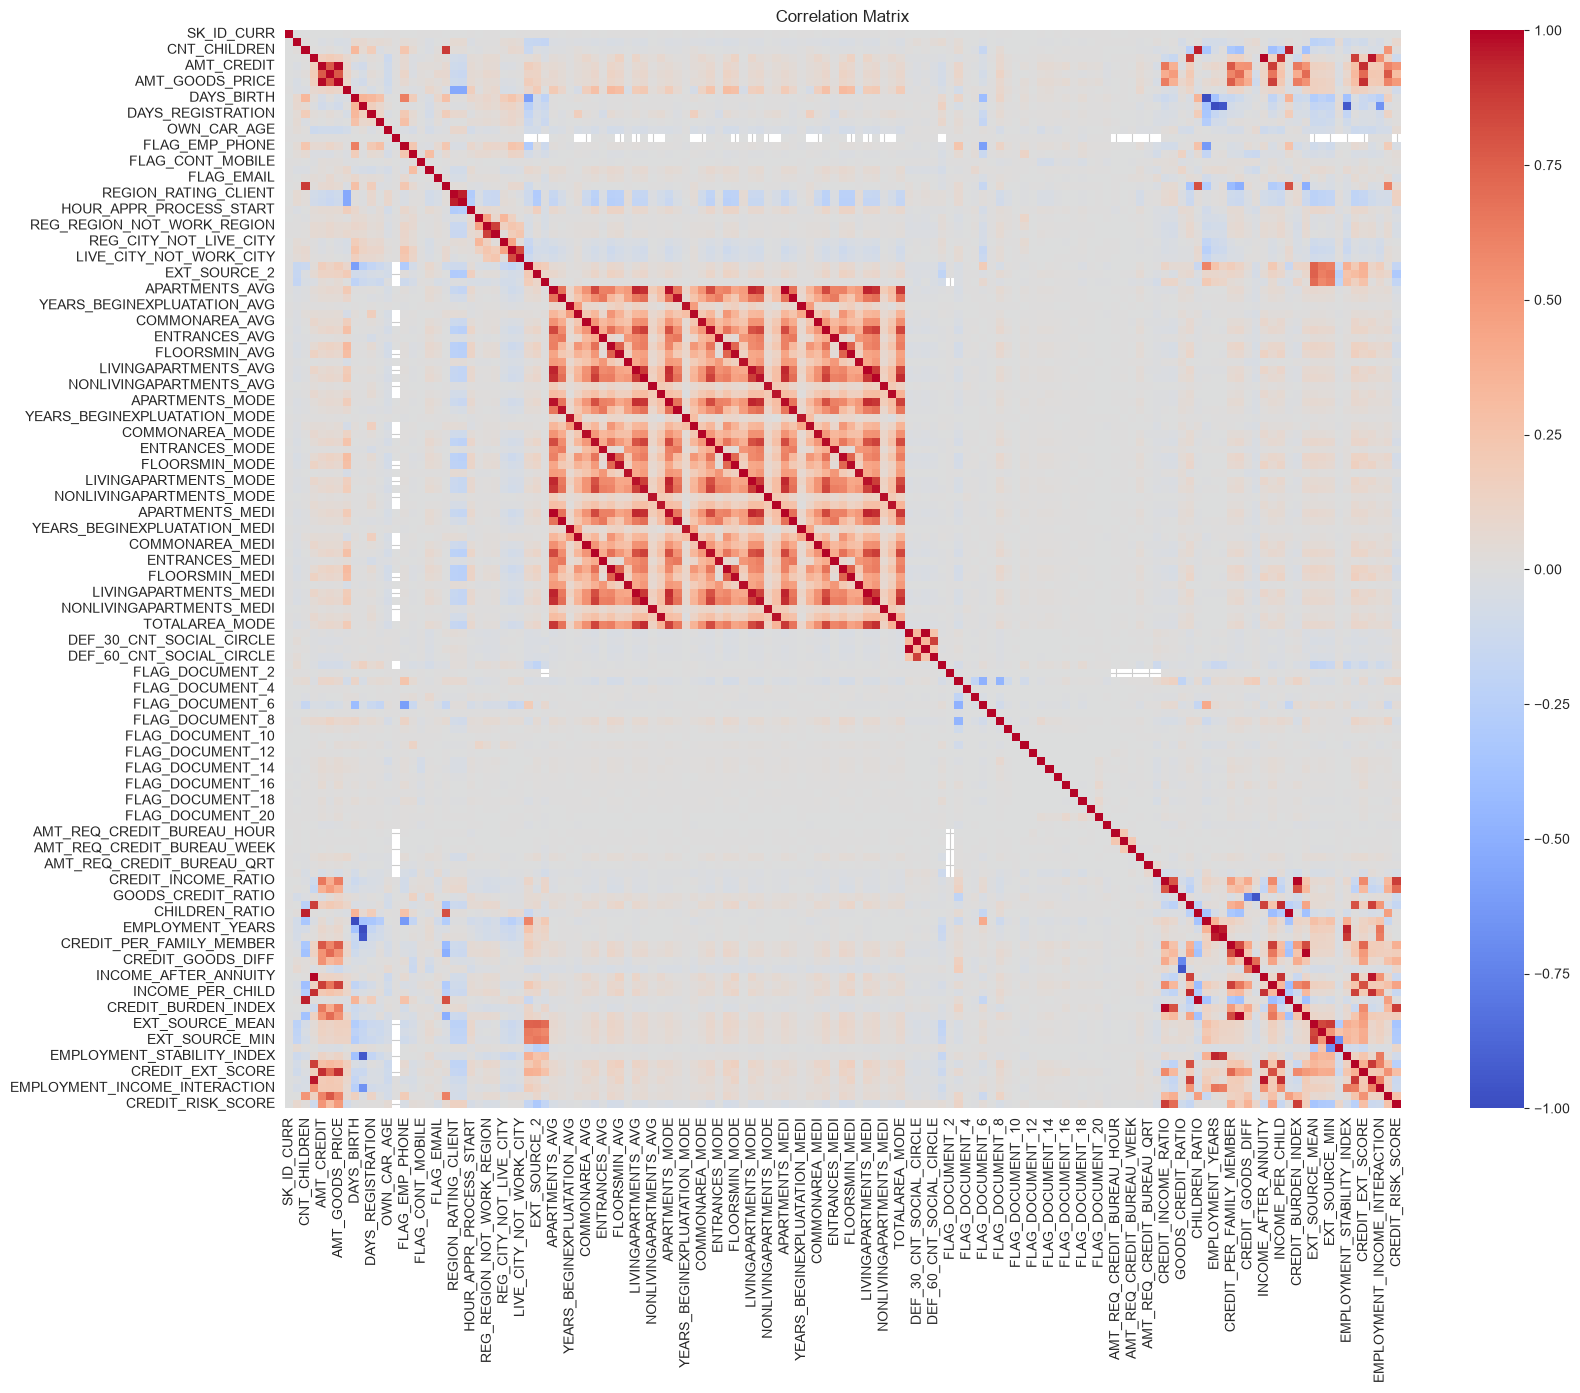

In [59]:
plt.figure(figsize=(18,14))

sns.heatmap(

    corr_matrix,

    cmap="coolwarm",

    center=0

)

plt.title("Correlation Matrix")

plt.show()

In [60]:
upper = corr_matrix.where(

    np.triu(

        np.ones(

            corr_matrix.shape

        ),

        k=1

    ).astype(bool)

)

high_corr = []

for col in upper.columns:

    for row in upper.index:

        corr = upper.loc[row,col]

        if pd.notnull(corr):

            if abs(corr)>0.90:

                high_corr.append({

                    "Feature 1":row,

                    "Feature 2":col,

                    "Correlation":round(corr,3)

                })

high_corr_df = pd.DataFrame(high_corr)

high_corr_df

,Feature 1,Feature 2,Correlation
0,AMT_CREDIT,AMT_GOODS_PRICE,0.987
1,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.951
2,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,0.944
3,APARTMENTS_AVG,LIVINGAREA_AVG,0.914
4,APARTMENTS_AVG,APARTMENTS_MODE,0.973
...,...,...,...
77,AMT_CREDIT,CREDIT_EXT_SCORE,0.915
78,AMT_GOODS_PRICE,CREDIT_EXT_SCORE,0.909
79,AMT_INCOME_TOTAL,AGE_INCOME_INTERACTION,0.967
80,INCOME_AFTER_ANNUITY,AGE_INCOME_INTERACTION,0.963


In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [62]:
engineered_features = feature_tracker.copy()

engineered_numeric = df_features[
    engineered_features
].select_dtypes(include=np.number)

engineered_numeric = engineered_numeric.fillna(
    engineered_numeric.median()
)

In [63]:
vif = pd.DataFrame()

vif["Feature"] = engineered_numeric.columns

vif["VIF"] = [

    variance_inflation_factor(

        engineered_numeric.values,

        i

    )

    for i in range(

        engineered_numeric.shape[1]

    )

]

vif.sort_values(

    by="VIF",

    ascending=False

)

,Feature,VIF
4,CHILDREN_RATIO,inf
9,ANNUITY_PER_FAMILY_MEMBER,inf
15,DEPENDENCY_RATIO,inf
17,FAMILY_FINANCIAL_BURDEN,inf
16,CREDIT_BURDEN_INDEX,3.526661e+05
0,CREDIT_INCOME_RATIO,3.260589e+05
18,EXT_SOURCE_MEAN,8.672963e+02
1,ANNUITY_INCOME_RATIO,6.296513e+02
19,EXT_SOURCE_MAX,3.755068e+02
20,EXT_SOURCE_MIN,1.617069e+02


In [64]:
feature_report = pd.DataFrame({

    "Metric":[

        "Original Features",

        "Engineered Features",

        "Total Features"

    ],

    "Value":[

        len(df.columns),

        len(feature_tracker),

        len(df_features.columns)

    ]

})

feature_report

,Metric,Value
0,Original Features,122
1,Engineered Features,30
2,Total Features,152


In [65]:
df_features.to_csv("application_train_engineered.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [66]:
feature_list = pd.DataFrame({"Engineered Feature":feature_tracker})

feature_list.to_csv("engineered_features.csv",index=False)